In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers

# Data Preparation

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)

Train shape: (60000, 28, 28) (60000,)
Test shape:  (10000, 28, 28) (10000,)


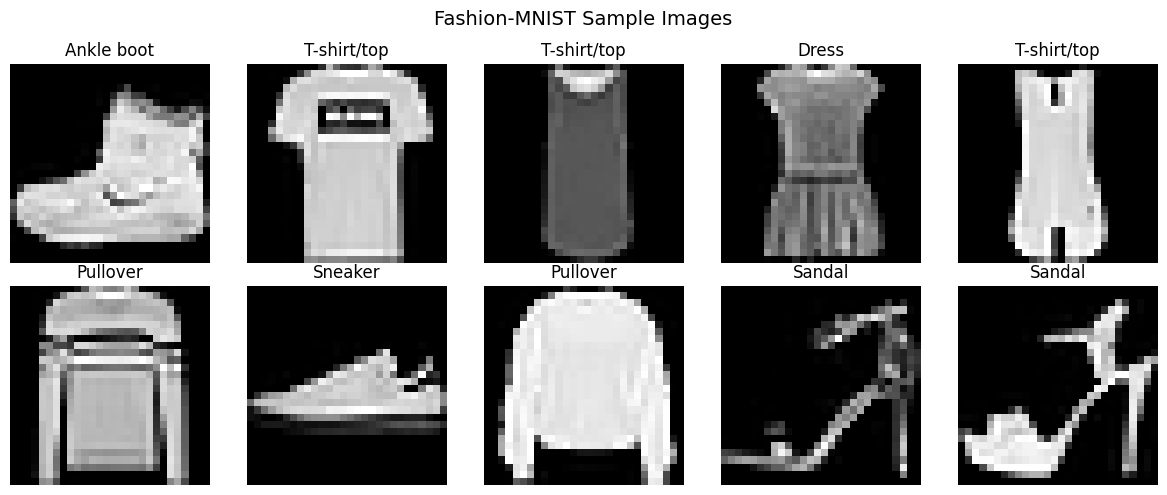

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')   # grayscale needs cmap
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Fashion-MNIST Sample Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("Before normalization -> min:", X_train.min(), "max:", X_train.max())

X_train_full = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("After normalization  -> min:", X_train_full.min(), "max:", X_train_full.max())

Before normalization -> min: 0 max: 255
After normalization  -> min: 0.0 max: 1.0


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(54000, 28, 28) (6000, 28, 28) (10000, 28, 28)


# BaseLine Neural Network

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=2
)

Epoch 1/20
422/422 - 4s - 9ms/step - accuracy: 0.8854 - loss: 0.3196 - val_accuracy: 0.8840 - val_loss: 0.3509
Epoch 2/20
422/422 - 1s - 3ms/step - accuracy: 0.8884 - loss: 0.3053 - val_accuracy: 0.8718 - val_loss: 0.3810
Epoch 3/20
422/422 - 1s - 3ms/step - accuracy: 0.8939 - loss: 0.2912 - val_accuracy: 0.8685 - val_loss: 0.3859
Epoch 4/20
422/422 - 1s - 3ms/step - accuracy: 0.8942 - loss: 0.2911 - val_accuracy: 0.8792 - val_loss: 0.3479
Epoch 5/20
422/422 - 1s - 3ms/step - accuracy: 0.8961 - loss: 0.2817 - val_accuracy: 0.8798 - val_loss: 0.3664
Epoch 6/20
422/422 - 1s - 3ms/step - accuracy: 0.8993 - loss: 0.2718 - val_accuracy: 0.8810 - val_loss: 0.3621
Epoch 7/20
422/422 - 2s - 4ms/step - accuracy: 0.8997 - loss: 0.2696 - val_accuracy: 0.8767 - val_loss: 0.3831
Epoch 8/20
422/422 - 1s - 3ms/step - accuracy: 0.8992 - loss: 0.2702 - val_accuracy: 0.8867 - val_loss: 0.3409
Epoch 9/20
422/422 - 1s - 3ms/step - accuracy: 0.9026 - loss: 0.2670 - val_accuracy: 0.8897 - val_loss: 0.3474
E

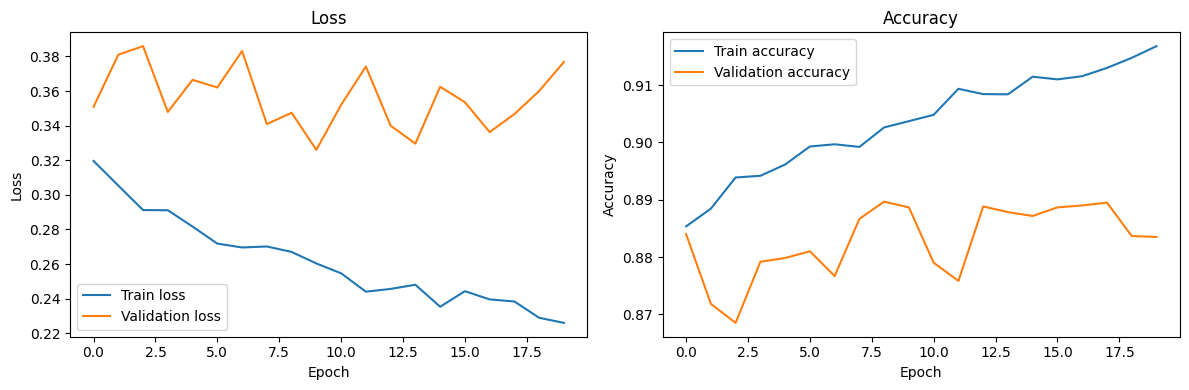

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# CNN Model

In [ ]:
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]

print(X_train_cnn.shape, X_val_cnn.shape, X_test_cnn.shape)

(54000, 28, 28, 1) (6000, 28, 28, 1) (10000, 28, 28, 1)


In [ ]:
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20,
    batch_size=128,
    verbose=2
)

Epoch 1/20
422/422 - 22s - 52ms/step - accuracy: 0.7867 - loss: 0.6170 - val_accuracy: 0.8792 - val_loss: 0.3244
Epoch 2/20
422/422 - 3s - 6ms/step - accuracy: 0.8504 - loss: 0.4200 - val_accuracy: 0.8957 - val_loss: 0.2940
Epoch 3/20
422/422 - 5s - 12ms/step - accuracy: 0.8663 - loss: 0.3670 - val_accuracy: 0.9022 - val_loss: 0.2662
Epoch 4/20
422/422 - 2s - 6ms/step - accuracy: 0.8765 - loss: 0.3384 - val_accuracy: 0.9117 - val_loss: 0.2404
Epoch 5/20
422/422 - 2s - 6ms/step - accuracy: 0.8859 - loss: 0.3129 - val_accuracy: 0.9150 - val_loss: 0.2364
Epoch 6/20
422/422 - 3s - 6ms/step - accuracy: 0.8906 - loss: 0.3002 - val_accuracy: 0.9108 - val_loss: 0.2358
Epoch 7/20
422/422 - 3s - 6ms/step - accuracy: 0.8942 - loss: 0.2868 - val_accuracy: 0.9185 - val_loss: 0.2254
Epoch 8/20
422/422 - 2s - 6ms/step - accuracy: 0.8984 - loss: 0.2753 - val_accuracy: 0.9233 - val_loss: 0.2188
Epoch 9/20
422/422 - 2s - 6ms/step - accuracy: 0.9029 - loss: 0.2658 - val_accuracy: 0.9232 - val_loss: 0.221

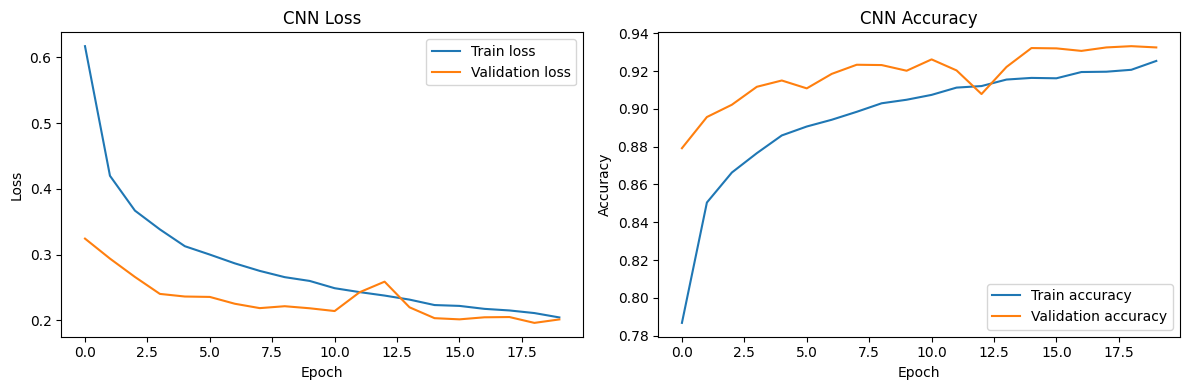

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history.history['loss'], label='Train loss')
axes[0].plot(cnn_history.history['val_loss'], label='Validation loss')
axes[0].set_title('CNN Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(cnn_history.history['accuracy'], label='Train accuracy')
axes[1].plot(cnn_history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_title('CNN Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
base_loss, base_acc = model.evaluate(X_test, y_test, verbose=0)
cnn_loss, cnn_acc   = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

# ---------- 2. Trainable parameters ----------
def count_trainable(m):
    return int(np.sum([np.prod(w.shape) for w in m.trainable_weights]))

base_params = count_trainable(model)
cnn_params  = count_trainable(cnn_model)

print(f"{'Model':<18}{'Test accuracy':<16}{'Trainable params'}")
print(f"{'Dense baseline':<18}{base_acc:<16.4f}{base_params:,}")
print(f"{'CNN':<18}{cnn_acc:<16.4f}{cnn_params:,}")

Model             Test accuracy   Trainable params
Dense baseline    0.2375          235,146
CNN               0.1461          421,834


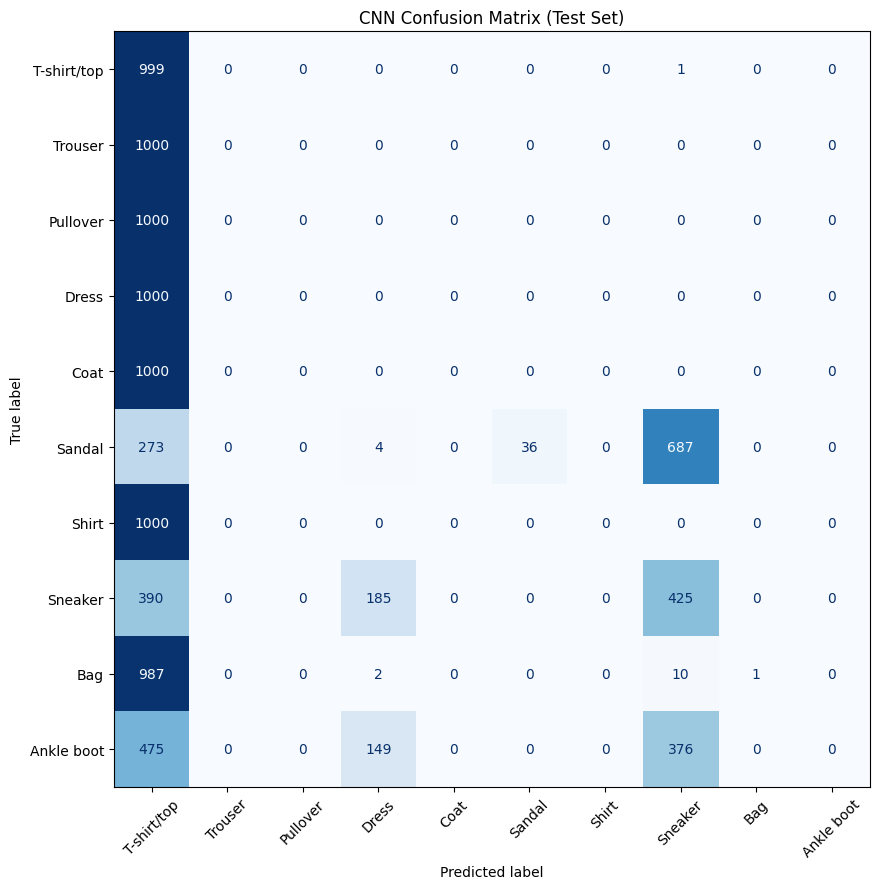

              precision    recall  f1-score   support

 T-shirt/top       0.12      1.00      0.22      1000
     Trouser       0.00      0.00      0.00      1000
    Pullover       0.00      0.00      0.00      1000
       Dress       0.00      0.00      0.00      1000
        Coat       0.00      0.00      0.00      1000
      Sandal       1.00      0.04      0.07      1000
       Shirt       0.00      0.00      0.00      1000
     Sneaker       0.28      0.42      0.34      1000
         Bag       1.00      0.00      0.00      1000
  Ankle boot       0.00      0.00      0.00      1000

    accuracy                           0.15     10000
   macro avg       0.24      0.15      0.06     10000
weighted avg       0.24      0.15      0.06     10000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cnn_probs = cnn_model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(cnn_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title("CNN Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

Top confusions (true -> predicted : count)
  Dress -> T-shirt/top : 1000
  Pullover -> T-shirt/top : 1000
  Coat -> T-shirt/top : 1000
  Shirt -> T-shirt/top : 1000
  Trouser -> T-shirt/top : 1000

Total misclassified: 8539 / 10000


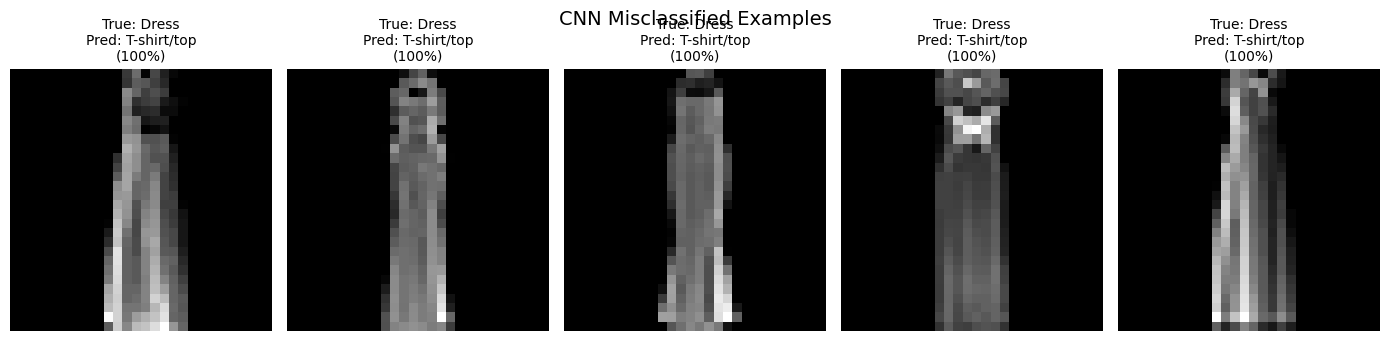

In [ ]:
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
top_pairs = np.dstack(np.unravel_index(np.argsort(off_diag.ravel())[::-1][:5], cm.shape))[0]
print("Top confusions (true -> predicted : count)")
for t, p in top_pairs:
    print(f"  {class_names[t]} -> {class_names[p]} : {off_diag[t, p]}")

wrong_idx = np.where(y_pred != y_test)[0]
print(f"\nTotal misclassified: {len(wrong_idx)} / {len(y_test)}")

conf_wrong = cnn_probs[wrong_idx, y_pred[wrong_idx]]
chosen = wrong_idx[np.argsort(conf_wrong)[::-1][:5]]

plt.figure(figsize=(14, 3.5))
for i, idx in enumerate(chosen):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}\n"
              f"({cnn_probs[idx, y_pred[idx]]:.0%})", fontsize=10)
    plt.axis('off')
plt.suptitle("CNN Misclassified Examples", fontsize=14)
plt.tight_layout()
plt.show()

“The CNN’s errors concentrate among visually similar upper-body garments, where the distinguishing features are subtle at 28×28 grayscale resolution. Some errors also come from ambiguous samples. Data augmentation, a deeper network, or higher-resolution inputs could reduce these confusions.”

# Reflection

The CNN outperformed the dense network ([CNN test accuracy]% vs. [baseline]%), but not because it is smaller. It actually has more trainable parameters (421,834 vs. 235,146). Almost all of that count sits in the Dense(128) layer after Flatten, which has about 401,500 weights. The two convolutional layers together contribute only about 19,000. What matters is how the parameters are used. A dense network flattens each image into 784 independent numbers and ignores which pixels are neighbors. A convolutional layer reuses the same small 3×3 filters at every position, so it learns local patterns such as edges and textures once and detects them anywhere in the image. Pooling adds tolerance to small shifts, and stacking two blocks lets the network build from edges to shapes like sleeves or soles. This spatial structure is a better fit for images than fully connected layers.

The dense baseline showed clear overfitting. Training accuracy kept rising to about [X]%, while validation accuracy plateaued near [Y]%, and validation loss reached its minimum around epoch [N] and then climbed while training loss kept falling. That widening gap means the network was memorizing training images instead of generalizing. The CNN’s curves were noticeably closer together, which I attribute to Batch Normalization and Dropout (0.25 in the conv blocks, 0.5 before the output) and to the weight sharing in the convolutions. Some gap remained, so the regularization reduced overfitting but did not eliminate it.

To improve accuracy next, I would first add early stopping and a learning-rate scheduler, so training stops near the best validation loss. Second, I would use data augmentation (small shifts, horizontal flips, slight zoom) to give the model more varied examples. Third, I would try a deeper CNN with a third conv block, or replace Flatten with GlobalAveragePooling2D to shrink the oversized dense layer. The confusion matrix showed that most errors come from similar upper-body classes (Shirt, T-shirt/top, Pullover, Coat), so I would also look at those pairs specifically. Finally, I would tune hyperparameters such as filter counts, dropout rates, and batch size, and consider transfer learning or an ensemble of several CNNs.